In [16]:
merged_approaches

,ID,lvl3,lvl2,lvl1,len_levels_complete
0,6,low-returns_fast-reframe,low-returns_fast-reframe,low-returns_fast-reframe,36
1,12,low-returns_fast-reframe,low-returns_slow-reframe,low-returns_fast-reframe,37
2,22,high-returns_fast-reframe,low-returns_fast-reframe,low-returns_fast-reframe,24
3,23,low-returns_fast-reframe,low-returns_slow-reframe,low-returns_fast-reframe,31
4,26,low-returns_fast-reframe,low-returns_slow-reframe,low-returns_fast-reframe,38
...,...,...,...,...,...
74,241,low-returns_fast-reframe,low-returns_fast-reframe,high-returns_fast-reframe,34
75,242,high-returns_fast-reframe,low-returns_slow-reframe,low-returns_fast-reframe,37
76,248,low-returns_fast-reframe,low-returns_fast-reframe,low-returns_fast-reframe,22
77,251,low-returns_slow-reframe,low-returns_fast-reframe,low-returns_fast-reframe,31


In [3]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Step 1: Load your data from CSV
# Adjust the file path as needed
file_path = '/Users/baselhussein/Downloads/merged_approaches.csv'
merged_approaches = pd.read_csv(file_path)

# Step 2: Encode categorical levels numerically
label_encoder = LabelEncoder()

merged_approaches['lvl1_encoded'] = label_encoder.fit_transform(merged_approaches['lvl1'])
merged_approaches['lvl2_encoded'] = label_encoder.transform(merged_approaches['lvl2'])
merged_approaches['lvl3_encoded'] = label_encoder.transform(merged_approaches['lvl3'])

# Step 3: Create sequences for LSTM input
sequences = merged_approaches[['lvl1_encoded', 'lvl2_encoded', 'lvl3_encoded']].values
targets = merged_approaches['len_levels_complete'].values

In [4]:
sequences

array([[1, 1, 1],
       [1, 2, 1],
       [1, 1, 0],
       [1, 2, 1],
       [1, 2, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 2, 0],
       [1, 2, 0],
       [1, 2, 1],
       [1, 1, 1],
       [2, 2, 1],
       [1, 2, 1],
       [1, 1, 1],
       [1, 2, 1],
       [1, 1, 1],
       [1, 1, 0],
       [1, 0, 1],
       [1, 1, 1],
       [1, 1, 2],
       [0, 1, 1],
       [1, 1, 1],
       [2, 2, 0],
       [1, 1, 1],
       [1, 1, 1],
       [2, 1, 1],
       [1, 2, 2],
       [1, 2, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 2],
       [1, 1, 0],
       [2, 2, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 0, 1],
       [2, 1, 2],
       [1, 1, 0],
       [2, 1, 1],
       [1, 0, 0],
       [1, 0, 1],
       [1, 1, 1],
       [1, 1, 0],
       [1, 2, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 2],
       [1, 1, 1],
       [0, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [0,

In [ ]:
#Reshape sequences for LSTM input
X_seq = sequences.reshape((sequences.shape[0], sequences.shape[1]))  # shape (samples, timesteps)
y_seq = targets

# Step 4: Define the LSTM model
model = Sequential()
model.add(Embedding(input_dim=len(label_encoder.classes_), output_dim=8, input_length=3))  # Embed each input feature into an 8-dimensional vector
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Step 5: Fit the model
model.fit(X_seq, y_seq, epochs=100, verbose=1)

# Step 6: Evaluate the model
preds = model.predict(X_seq)
mse = np.mean((preds.flatten() - y_seq) ** 2)
print(f'Mean Squared Error: {mse}')

In [5]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from sklearn.model_selection import KFold
import numpy as np

# Step 1: Load your data from CSV
# Adjust the file path as needed
#file_path = 'your_file_path.csv'
merged_approaches = pd.read_csv(file_path)

# Step 2: Encode categorical levels numerically
label_encoder = LabelEncoder()

merged_approaches['lvl1_encoded'] = label_encoder.fit_transform(merged_approaches['lvl1'])
merged_approaches['lvl2_encoded'] = label_encoder.transform(merged_approaches['lvl2'])
merged_approaches['lvl3_encoded'] = label_encoder.transform(merged_approaches['lvl3'])

# Step 3: Create sequences for LSTM input
sequences = merged_approaches[['lvl1_encoded', 'lvl2_encoded', 'lvl3_encoded']].values
targets = merged_approaches['len_levels_complete'].values

# Reshape sequences for LSTM input
X_seq = sequences.reshape((sequences.shape[0], sequences.shape[1]))  # shape (samples, timesteps)
y_seq = targets

# Step 4: Set up k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores = []

# Function to create and compile LSTM model
def create_model():
    model = Sequential()
    model.add(Embedding(input_dim=len(label_encoder.classes_), output_dim=8, input_length=3))
    model.add(LSTM(50, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Step 5: Perform cross-validation
for train_index, val_index in kf.split(X_seq):
    X_train, X_val = X_seq[train_index], X_seq[val_index]
    y_train, y_val = y_seq[train_index], y_seq[val_index]
    
    # Create and train the model
    model = create_model()
    model.fit(X_train, y_train, epochs=100, verbose=0)
    
    # Evaluate the model
    preds = model.predict(X_val)
    mse = np.mean((preds.flatten() - y_val) ** 2)
    mse_scores.append(mse)

# Step 6: Calculate average MSE across all folds
average_mse = np.mean(mse_scores)
print(f'Average Mean Squared Error across all folds: {average_mse}')

/Users/baselhussein/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Average Mean Squared Error across all folds: 144.35500179345723


In [6]:
import numpy as np

# Calculate the mean of len_levels_complete as a baseline prediction
baseline_prediction = merged_approaches['len_levels_complete'].mean()

# Calculate MSE for the baseline model
baseline_mse = np.mean((merged_approaches['len_levels_complete'] - baseline_prediction) ** 2)

print(f'Baseline MSE: {baseline_mse}')

Baseline MSE: 144.87453933664477


In [7]:
baseline_prediction

37.31645569620253

In [8]:
# Import necessary libraries
import pandas as pd

# Step 1: Load your data from CSV
# Adjust the file path as needed
merged_approaches = pd.read_csv(file_path)

# Step 2: Create a sequence column representing the order of strategies
merged_approaches['sequence'] = merged_approaches['lvl1'] + ' -> ' + merged_approaches['lvl2'] + ' -> ' + merged_approaches['lvl3']

# Step 3: Group by sequence and calculate the average number of levels completed
sequence_performance = merged_approaches.groupby('sequence')['len_levels_complete'].mean().reset_index()

# Step 4: Sort sequences by average levels completed to identify top-performing sequences
sequence_performance_sorted = sequence_performance.sort_values(by='len_levels_complete', ascending=False)

# Display the sorted sequences and their average levels completed
print(sequence_performance_sorted)

                                             sequence  len_levels_complete
11  low-returns_slow-reframe -> low-returns_fast-r...            45.000000
6   low-returns_fast-reframe -> low-returns_fast-r...            42.187500
10  low-returns_fast-reframe -> low-returns_slow-r...            42.000000
3   low-returns_fast-reframe -> high-returns_fast-...            40.000000
8   low-returns_fast-reframe -> low-returns_slow-r...            37.750000
15  low-returns_slow-reframe -> low-returns_slow-r...            36.500000
2   high-returns_fast-reframe -> low-returns_fast-...            35.500000
9   low-returns_fast-reframe -> low-returns_slow-r...            34.818182
7   low-returns_fast-reframe -> low-returns_fast-r...            32.000000
14  low-returns_slow-reframe -> low-returns_slow-r...            32.000000
12  low-returns_slow-reframe -> low-returns_fast-r...            31.666667
4   low-returns_fast-reframe -> high-returns_fast-...            31.600000
1   high-returns_fast-ref

In [24]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

/Users/baselhussein/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/Users/baselhussein/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/Users/baselhussein/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/Users/baselhussein/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/Users/baselhussein/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Average Mean Squared Error (MSE) across all folds: 144.3966164260158
Average Mean Absolute Error (MAE) across all folds: 8.904800628026326
Average R-squared (R²) across all folds: -0.0873113185736433


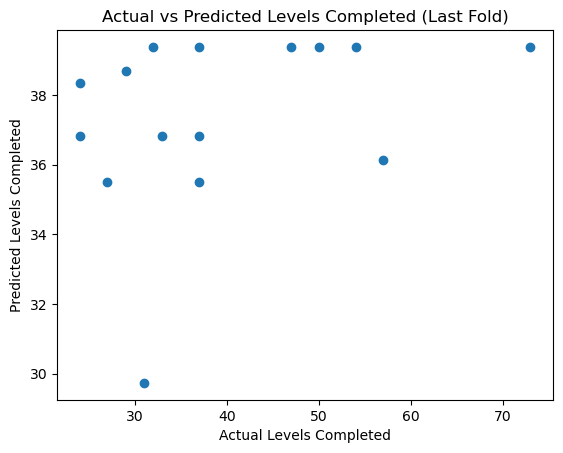

In [26]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

mae_scores = []
r2_scores = []

# Perform cross-validation and collect additional metrics
for train_index, val_index in kf.split(X_seq):
    X_train, X_val = X_seq[train_index], X_seq[val_index]
    y_train, y_val = y_seq[train_index], y_seq[val_index]
    
    # Create and train the model
    model = create_model()
    model.fit(X_train, y_train, epochs=100, verbose=0)
    
    # Evaluate the model
    preds = model.predict(X_val).flatten()
    mse = mean_squared_error(y_val, preds)
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)

# Calculate average metrics across all folds
average_mse = np.mean(mse_scores)
average_mae = np.mean(mae_scores)
average_r2 = np.mean(r2_scores)

print(f'Average Mean Squared Error (MSE) across all folds: {average_mse}')
print(f'Average Mean Absolute Error (MAE) across all folds: {average_mae}')
print(f'Average R-squared (R²) across all folds: {average_r2}')

# Optional: Visualize predictions vs actuals for the last fold
plt.scatter(y_val, preds)
plt.xlabel('Actual Levels Completed')
plt.ylabel('Predicted Levels Completed')
plt.title('Actual vs Predicted Levels Completed (Last Fold)')
plt.show()